##Project 3: Machine Learning for Predicting Trading Signals##
#Name Ayleen Santander

In [60]:
#Import Libraries
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

RANDOM_STATE = 42
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 160)

In [2]:
#Load dataset
PRICES_PATH = 'historical_stock_prices.csv'
START_DATE = '2010-01-01'          # same scope as Project 2 (decade 2010)

s_p3 = pd.read_csv(PRICES_PATH,
                 usecols=['ticker', 'open', 'high', 'low', 'close', 'date'],
                 low_memory=False)
print(f"Raw rows: {len(s_p3):,}")

s_p3['date'] = pd.to_datetime(s_p3['date'], errors='coerce')
s_p3 = s_p3[s_p3['date'] >= START_DATE].copy()
print(f"Rows from {START_DATE}: {len(s_p3):,}")


Raw rows: 20,973,889
Rows from 2010-01-01: 9,338,934


In [3]:
#Cleaning Data
rows_start = len(s_p3)
s_p3['ticker'] = s_p3['ticker'].astype(str).str.strip().str.upper()
s_p3 = s_p3.dropna(subset=['date', 'close'])
s_p3 = s_p3.drop_duplicates(subset=['ticker', 'date'])

bad_ohlc = ((s_p3['low'] > s_p3['high']) |
            (s_p3['close'] > s_p3['high']) | (s_p3['close'] < s_p3['low']) |
            (s_p3['open'] > s_p3['high'])  | (s_p3['open'] < s_p3['low']))
print(f"Contradictory OHLC rows removed: {bad_ohlc.sum():,}")
s_p3 = s_p3[~bad_ohlc]
s_p3 = s_p3[s_p3['close'] > 0]

s_p3 = s_p3.sort_values(['ticker', 'date']).reset_index(drop=True)
print(f"Rows: {rows_start:,} -> {len(s_p3):,}")
print(f"Tickers: {s_p3['ticker'].nunique():,} | Dates: {s_p3['date'].min().date()} to {s_p3['date'].max().date()}")

Contradictory OHLC rows removed: 1,348
Rows: 9,338,934 -> 9,337,586
Tickers: 5,685 | Dates: 2010-01-04 to 2018-08-24


In [4]:
#Rebuild 6 previous features (P.2)
FEATURES = ['daily_return', 'close_lag_1', 'ma_5', 'ma_20', 'volatility_20', 'daily_range_pct']

g = s_p3.groupby('ticker')['close']
s_p3['close_lag_1']     = g.shift(1)
s_p3['daily_return']    = g.pct_change(fill_method=None)
s_p3['ma_5']            = g.transform(lambda s: s.rolling(5).mean())
s_p3['ma_20']           = g.transform(lambda s: s.rolling(20).mean())
s_p3['volatility_20']   = s_p3.groupby('ticker')['daily_return'].transform(lambda s: s.rolling(20).std())
s_p3['daily_range_pct'] = (s_p3['high'] - s_p3['low']) / s_p3['close']

# Same leakage check as Project 2: first row of every ticker must have no lag/rolling values
first = s_p3.groupby('ticker').head(1)
print(first[['close_lag_1', 'ma_5', 'ma_20', 'volatility_20']].notna().sum())

close_lag_1      0
ma_5             0
ma_20            0
volatility_20    0
dtype: int64


##Part 1: P.3. Feature Engineering with Technical Indicators

In [5]:
#Manual EMA function (no ewm, no TA library)
is_first = (s_p3['ticker'] != s_p3['ticker'].shift(1)).to_numpy()   # True on each ticker's first row

def manual_ema(values, alpha, is_first=is_first):
    """EMA_t = alpha * x_t + (1 - alpha) * EMA_(t-1), restarting at each new ticker."""
    x = np.asarray(values, dtype=float).tolist()   # plain lists make the Python loop faster
    starts = is_first.tolist()
    out = [0.0] * len(x)
    prev = 0.0
    for i in range(len(x)):
        if starts[i]:
            prev = x[i]                              # seed with the first value of the ticker
        else:
            prev = alpha * x[i] + (1 - alpha) * prev
        out[i] = prev
    return np.array(out)

def span_alpha(span):
    return 2 / (span + 1)

In [6]:
#MACD and MACD signal
t0 = time.time()
s_p3['ema_12'] = manual_ema(s_p3['close'], span_alpha(12))
s_p3['ema_26'] = manual_ema(s_p3['close'], span_alpha(26))
s_p3['macd'] = s_p3['ema_12'] - s_p3['ema_26']
s_p3['macd_signal_line'] = manual_ema(s_p3['macd'], span_alpha(9))
print(f"MACD computed in {time.time() - t0:.0f}s")

diff_today = s_p3['macd'] - s_p3['macd_signal_line']      # > 0 means MACD is above the signal line
diff_yesterday = diff_today.shift(1)
diff_yesterday[is_first] = np.nan                        # no "yesterday" on a ticker's first row

s_p3['macd_action'] = np.select(
    [(diff_yesterday <= 0) & (diff_today > 0),
     (diff_yesterday >= 0) & (diff_today < 0)],
    ['Buy', 'Sell'],
    default='Hold'
)
s_p3['macd_action'].value_counts()

MACD computed in 7s


macd_action
Hold    8563342
Buy      387555
Sell     386689
Name: count, dtype: int64

In [7]:
#RSI and RSI signal
t0 = time.time()
change = s_p3['close'].diff()
change[is_first] = 0.0                                  # never compare with another ticker's price
gain = change.clip(lower=0)
loss = (-change).clip(lower=0)

avg_gain = manual_ema(gain, 1 / 14)
avg_loss = manual_ema(loss, 1 / 14)
with np.errstate(divide='ignore', invalid='ignore'):
    rs = avg_gain / avg_loss
    s_p3['rsi_14'] = 100 - (100 / (1 + rs))               # avg_loss = 0 -> RSI = 100
print(f"RSI computed in {time.time() - t0:.0f}s")

s_p3['rsi_action'] = np.select(
    [s_p3['rsi_14'] < 30, s_p3['rsi_14'] > 70],
    ['Buy', 'Sell'],
    default='Hold'
)
s_p3['rsi_action'].value_counts()

RSI computed in 4s


rsi_action
Hold    8379167
Sell     574963
Buy      383456
Name: count, dtype: int64

In [12]:
# Combined trading signal
s_p3['trading_signal'] = np.select(
    [(s_p3['macd_action'] == 'Buy')  & (s_p3['rsi_action'] == 'Buy'),
     (s_p3['macd_action'] == 'Sell') & (s_p3['rsi_action'] == 'Sell')],
    ['Buy', 'Sell'],
    default='Hold'
)

# Warm-up removal (runs only once)
WARMUP = 35
rows_before = len(s_p3)

if 'ema_12' in s_p3.columns:
    s_p3 = s_p3[s_p3.groupby('ticker').cumcount() >= WARMUP].reset_index(drop=True)
    s_p3 = s_p3.drop(columns=['ema_12', 'ema_26'])   # free memory; not needed any more
    print(f"Removed {rows_before - len(s_p3):,} warm-up rows. Remaining: {len(s_p3):,}")
else:
    print("Warm-up already removed, skipping.")

# Signal distribution
CLASS_NAMES = ['Buy', 'Hold', 'Sell']
signal_counts = s_p3['trading_signal'].value_counts().reindex(CLASS_NAMES, fill_value=0)
signal_pct = signal_counts / signal_counts.sum() * 100
signal_table = pd.DataFrame({'count': signal_counts, 'percent': signal_pct.round(4)})
signal_table

Warm-up already removed, skipping.


,count,percent
trading_signal,,
Buy,3170,0.0355
Hold,8933470,99.9131
Sell,4596,0.0514


In [10]:
print(s_p3.head())

  ticker    open   close     low    high       date  close_lag_1  daily_return    ma_5   ma_20  volatility_20  daily_range_pct   macd  macd_signal_line  \
0      A 24.6423 25.4864 24.4778 25.6867 2010-04-15      24.6137        0.0355 24.6609 24.5161         0.0113           0.0474 0.3771            0.4113   
1      A 25.4220 25.2289 25.0858 25.6795 2010-04-16      25.4864       -0.0101 24.8097 24.5808         0.0117           0.0235 0.3973            0.4085   
2      A 25.2790 25.1502 24.7854 25.3505 2010-04-19      25.2289       -0.0031 24.9456 24.6431         0.0118           0.0225 0.4023            0.4073   
3      A 25.3076 25.9585 25.3076 26.0873 2010-04-20      25.1502        0.0321 25.2876 24.7350         0.0134           0.0300 0.4662            0.4191   
4      A 25.8798 25.8441 25.6009 26.0300 2010-04-21      25.9585       -0.0044 25.5336 24.8072         0.0134           0.0166 0.5017            0.4356   

  macd_action  rsi_14 rsi_action trading_signal  
0        Hold 70.83

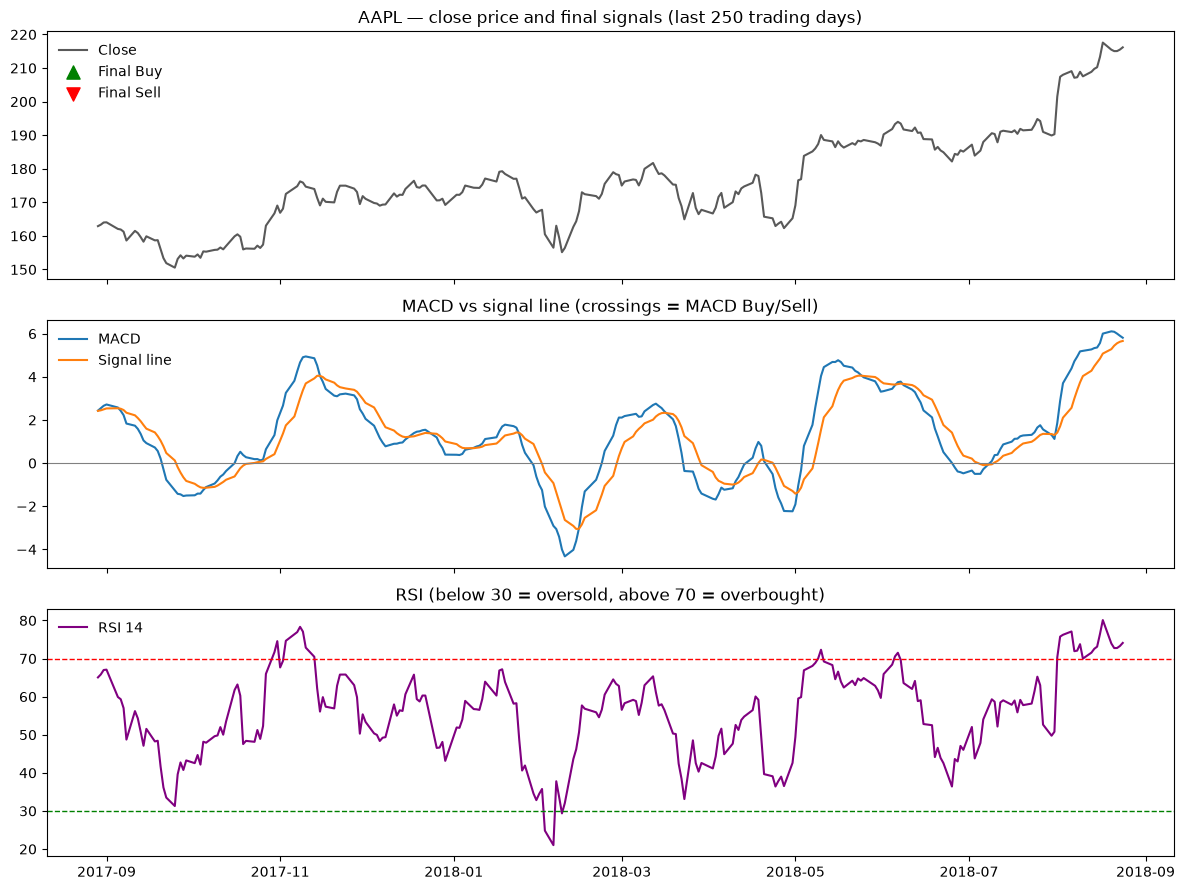

In [11]:
#Chart of the indicators for one stock
example_ticker = 'AAPL' if 'AAPL' in set(s_p3['ticker']) else s_p3['ticker'].value_counts().index[0]
ex = s_p3[s_p3['ticker'] == example_ticker].tail(250)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(ex['date'], ex['close'], color='0.35', label='Close')
for sig, color, marker in [('Buy', 'green', '^'), ('Sell', 'red', 'v')]:
    pts = ex[ex['trading_signal'] == sig]
    axes[0].scatter(pts['date'], pts['close'], color=color, marker=marker, s=90, label=f'Final {sig}', zorder=3)
axes[0].set_title(f'{example_ticker} — close price and final signals (last 250 trading days)')
axes[0].legend(frameon=False)

axes[1].plot(ex['date'], ex['macd'], label='MACD')
axes[1].plot(ex['date'], ex['macd_signal_line'], label='Signal line')
axes[1].axhline(0, color='grey', lw=0.8)
axes[1].set_title('MACD vs signal line (crossings = MACD Buy/Sell)')
axes[1].legend(frameon=False)

axes[2].plot(ex['date'], ex['rsi_14'], color='purple', label='RSI 14')
axes[2].axhline(70, color='red', ls='--', lw=1)
axes[2].axhline(30, color='green', ls='--', lw=1)
axes[2].set_title('RSI (below 30 = oversold, above 70 = overbought)')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.savefig('fig_indicators_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Part 1 answers:


In [13]:
n, p = signal_counts, signal_pct
total = n.sum()
macd_buy = (s_p3['macd_action'] == 'Buy').sum()
macd_sell = (s_p3['macd_action'] == 'Sell').sum()
rsi_buy = (s_p3['rsi_action'] == 'Buy').sum()
rsi_sell = (s_p3['rsi_action'] == 'Sell').sum()
rsi_on_macd_buy = s_p3.loc[s_p3['macd_action'] == 'Buy', 'rsi_14'].median()
rsi_on_macd_sell = s_p3.loc[s_p3['macd_action'] == 'Sell', 'rsi_14'].median()

print("Q1. How many Buy, Sell and Hold signals were generated?")
print(f"    Buy : {n['Buy']:>10,}  ({p['Buy']:.4f}%)")
print(f"    Sell: {n['Sell']:>10,}  ({p['Sell']:.4f}%)")
print(f"    Hold: {n['Hold']:>10,}  ({p['Hold']:.4f}%)")
print(f"    Total rows: {total:,}\n")

print("Q2. Which signal occurs most frequently?")
print(f"    {n.idxmax()} — {p.max():.2f}% of all rows.\n")

print("Q3. Evidence for why Buy/Sell are rare:")
print(f"    MACD crossed ABOVE its signal line on {macd_buy:,} days ({macd_buy/total:.2%} of rows)")
print(f"    RSI was below 30 on {rsi_buy:,} days ({rsi_buy/total:.2%} of rows)")
print(f"    Both on the SAME day (final Buy): {n['Buy']:,}")
print(f"    Median RSI on MACD Buy-crossover days: {rsi_on_macd_buy:.1f}  (a final Buy needs < 30)")
print(f"    MACD crossed BELOW on {macd_sell:,} days; RSI above 70 on {rsi_sell:,} days; both: {n['Sell']:,}")
print(f"    Median RSI on MACD Sell-crossover days: {rsi_on_macd_sell:.1f}  (a final Sell needs > 70)\n")

print("Q4. Distribution of the target:")
print(f"    About {n['Hold'] / max(n['Buy'], 1):,.0f} Hold rows for every Buy row "
      f"and {n['Hold'] / max(n['Sell'], 1):,.0f} for every Sell row.")
print(f"    A model that always predicts Hold would already be {p['Hold']:.2f}% 'accurate'.")

Q1. How many Buy, Sell and Hold signals were generated?
    Buy :      3,170  (0.0355%)
    Sell:      4,596  (0.0514%)
    Hold:  8,933,470  (99.9131%)
    Total rows: 8,941,236

Q2. Which signal occurs most frequently?
    Hold — 99.91% of all rows.

Q3. Evidence for why Buy/Sell are rare:
    MACD crossed ABOVE its signal line on 368,587 days (4.12% of rows)
    RSI was below 30 on 348,626 days (3.90% of rows)
    Both on the SAME day (final Buy): 3,170
    Median RSI on MACD Buy-crossover days: 54.0  (a final Buy needs < 30)
    MACD crossed BELOW on 368,189 days; RSI above 70 on 523,153 days; both: 4,596
    Median RSI on MACD Sell-crossover days: 48.1  (a final Sell needs > 70)

Q4. Distribution of the target:
    About 2,818 Hold rows for every Buy row and 1,944 for every Sell row.
    A model that always predicts Hold would already be 99.91% 'accurate'.


In [20]:
#Part 2: class imbalance check
n = signal_table['count']
p = signal_table['percent']

print(signal_table, "\n")
for cls in CLASS_NAMES:
    ratio = n.max() / n[cls] if n[cls] else float('inf')
    print(f"{cls:>5}: {n[cls]:>10,}  ({p[cls]:.4f}%)   majority-to-class ratio = {ratio:,.0f} : 1")

                  count  percent
trading_signal                  
Buy                3170   0.0355
Hold            8933470  99.9131
Sell               4596   0.0514 

  Buy:      3,170  (0.0355%)   majority-to-class ratio = 2,818 : 1
 Hold:  8,933,470  (99.9131%)   majority-to-class ratio = 1 : 1
 Sell:      4,596  (0.0514%)   majority-to-class ratio = 1,944 : 1


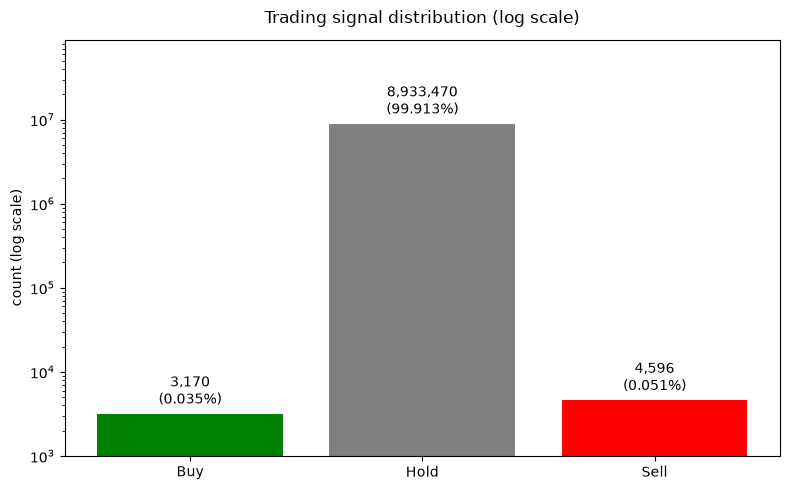

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

counts = signal_table['count']
pcts = signal_table['percent']
colors = ['green', 'grey', 'red']

bars = ax.bar(CLASS_NAMES, counts, color=colors)
ax.set_yscale('log')

# Headroom: on a log scale, multiply the max to make space for labels
ax.set_ylim(bottom=1_000, top=counts.max() * 10)

for bar, c, p in zip(bars, counts, pcts):
    ax.annotate(f"{c:,}\n({p:.3f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, c),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=10)

ax.set_title('Trading signal distribution (log scale)', pad=12)
ax.set_ylabel('count (log scale)')
plt.tight_layout()
plt.savefig('trading_signal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

##Part 2: Data Preparation and Splitting

In [22]:
#Part 3: prepare features and target
LEAKAGE_COLS = ['macd', 'macd_signal_line', 'macd_action', 'rsi_14', 'rsi_action']
assert not set(FEATURES) & set(LEAKAGE_COLS), "Leakage column found in FEATURES!"

LABEL_MAP = {'Buy': 0, 'Hold': 1, 'Sell': 2}
LABELS = [0, 1, 2]

model_s_p3 =s_p3[['ticker', 'date'] + FEATURES + ['trading_signal']].copy()
model_s_p3[FEATURES] = model_s_p3[FEATURES].replace([np.inf, -np.inf], np.nan)
rows_before = len(model_s_p3)
model_s_p3 = model_s_p3.dropna(subset=FEATURES).reset_index(drop=True)
model_s_p3['target'] = model_s_p3['trading_signal'].map(LABEL_MAP).astype(int)

print(f"Rows removed for missing/infinite feature values: {rows_before - len(model_s_p3):,}")
print("Label mapping:", LABEL_MAP)
model_s_p3[FEATURES].describe().T

Rows removed for missing/infinite feature values: 0
Label mapping: {'Buy': 0, 'Hold': 1, 'Sell': 2}


,count,mean,std,min,25%,50%,75%,max
daily_return,8941236.0000,0.3831,130.2521,-1.0000,-0.0095,0.0000,0.0098,159814.7320
close_lag_1,8941236.0000,60.3522,1373.8036,0.0010,10.3500,20.1800,38.8300,318800.0000
ma_5,8941236.0000,60.3782,1361.2757,0.0010,10.3580,20.1860,38.8180,307240.0000
ma_20,8941236.0000,60.6121,1332.1844,0.0010,10.3755,20.1845,38.7310,280675.0000
volatility_20,8941236.0000,1.0976,127.6663,0.0000,0.0112,0.0174,0.0275,35890.1630
daily_range_pct,8941236.0000,0.0313,0.5123,0.0000,0.0131,0.0222,0.0376,850.5000


In [23]:
#Part 4: Chronological split 
CUT_VAL, CUT_TEST = pd.Timestamp('2015-01-01'), pd.Timestamp('2017-01-01')

train = model_s_p3[model_s_p3['date'] < CUT_VAL]
val   = model_s_p3[(model_s_p3['date'] >= CUT_VAL) & (model_s_p3['date'] < CUT_TEST)]
test  = model_s_p3[model_s_p3['date'] >= CUT_TEST]

for name, part in [('Train', train), ('Validation', val), ('Test', test)]:
    print(f"{name:<11} {len(part):>10,} rows   {part['date'].min().date()} -> {part['date'].max().date()}")
print("Overlap train/val:", train['date'].max() >= val['date'].min(),
      "| Overlap val/test:", val['date'].max() >= test['date'].min())

split_dist = pd.DataFrame({
    'train %': train['trading_signal'].value_counts(normalize=True) * 100,
    'val %':   val['trading_signal'].value_counts(normalize=True) * 100,
    'test %':  test['trading_signal'].value_counts(normalize=True) * 100,
}).reindex(CLASS_NAMES).fillna(0)
split_dist


Train        4,430,337 rows   2010-04-15 -> 2014-12-31
Validation   2,354,977 rows   2015-01-02 -> 2016-12-30
Test         2,155,922 rows   2017-01-03 -> 2018-08-24
Overlap train/val: False | Overlap val/test: False


,train %,val %,test %
trading_signal,,,
Buy,0.0262,0.0488,0.0400
Hold,99.9244,99.9059,99.8979
Sell,0.0494,0.0453,0.0621


In [24]:
#Outlier clipping and scalling (fit on trainn only)
X_train_raw, X_val_raw, X_test_raw = train[FEATURES], val[FEATURES], test[FEATURES]
y_train, y_val, y_test = train['target'].to_numpy(), val['target'].to_numpy(), test['target'].to_numpy()

lower = X_train_raw.quantile(0.005)
upper = X_train_raw.quantile(0.995)
clip_limits = pd.DataFrame({'lower (0.5%)': lower, 'upper (99.5%)': upper})
print(clip_limits, "\n")

X_train_c = X_train_raw.clip(lower, upper, axis=1)
X_val_c   = X_val_raw.clip(lower, upper, axis=1)
X_test_c  = X_test_raw.clip(lower, upper, axis=1)

scaler = StandardScaler().fit(X_train_c)          # train only
X_train_s = scaler.transform(X_train_c)
X_val_s   = scaler.transform(X_val_c)
X_test_s  = scaler.transform(X_test_c)

print("Train mean after scaling (≈0):", X_train_s.mean(axis=0).round(3))
print("Train std  after scaling (≈1):", X_train_s.std(axis=0).round(3))

                 lower (0.5%)  upper (99.5%)
daily_return          -0.0966         0.1125
close_lag_1            0.9700       708.6207
ma_5                   0.9840       718.2359
ma_20                  1.0000       727.9355
volatility_20          0.0027         0.1392
daily_range_pct        0.0000         0.1846 

Train mean after scaling (≈0): [ 0.  0. -0.  0. -0.  0.]
Train std  after scaling (≈1): [1. 1. 1. 1. 1. 1.]


In [38]:
#Part 5: stratified training samples
def stratified_sample(X, y, n, seed=RANDOM_STATE):
    """Class-stratified sample of about n rows (each class keeps its share)."""
    if len(y) <= n:
        return X, y
    pos = (pd.Series(np.arange(len(y)))
             .groupby(y)
             .sample(frac=n / len(y), random_state=seed)
             .to_numpy())
    pos= np.sort(pos)
    return X[pos], y[pos]

def class_counts(y):
    return pd.Series(y).map(dict(enumerate(CLASS_NAMES))).value_counts().reindex(CLASS_NAMES, fill_value=0).to_dict()

SAMPLE_SIZES = {'Logistic Regression': 1_000_000, 'Random Forest': 300_000, 'SVM (linear)': 500_000}
samples = {}
for name, size in SAMPLE_SIZES.items():
    samples[name] = stratified_sample(X_train_s, y_train, size)
    print(f"{name:<20} rows: {len(samples[name][1]):>9,}   classes: {class_counts(samples[name][1])}")

Logistic Regression  rows: 1,000,000   classes: {'Buy': 262, 'Hold': 999244, 'Sell': 494}
Random Forest        rows:   299,999   classes: {'Buy': 78, 'Hold': 299773, 'Sell': 148}
SVM (linear)         rows:   500,000   classes: {'Buy': 131, 'Hold': 499622, 'Sell': 247}


In [39]:
#Train the baseline models
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
    'SVM (linear)': LinearSVC(C=1.0, dual=False, max_iter=5000, random_state=RANDOM_STATE),
}

trained = {}
for name, model in baseline_models.items():
    Xs, ys = samples[name]
    t0 = time.time()
    model.fit(Xs, ys)
    trained[name] = model
    print(f"{name:<20} trained in {time.time() - t0:.1f}s")

Logistic Regression  trained in 1.6s
Random Forest        trained in 14.9s
SVM (linear)         trained in 1.8s


In [40]:
print(samples.keys())

dict_keys(['Logistic Regression', 'Random Forest', 'SVM (linear)'])


Reference: accuracy of ALWAYS predicting Hold on validation = 99.9059%

===== Logistic Regression — Validation =====
              precision    recall  f1-score   support

         Buy     0.0000    0.0000    0.0000      1149
        Hold     0.9991    1.0000    0.9995   2352761
        Sell     0.0000    0.0000    0.0000      1067

    accuracy                         0.9991   2354977
   macro avg     0.3330    0.3333    0.3332   2354977
weighted avg     0.9981    0.9991    0.9986   2354977



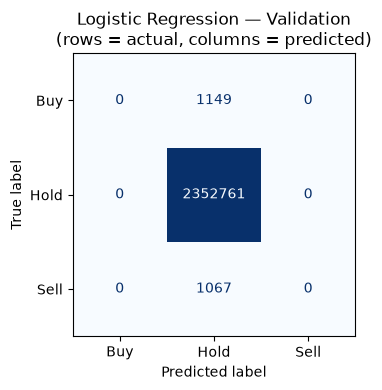

===== Random Forest — Validation =====
              precision    recall  f1-score   support

         Buy     0.0000    0.0000    0.0000      1149
        Hold     0.9991    1.0000    0.9995   2352761
        Sell     0.0000    0.0000    0.0000      1067

    accuracy                         0.9991   2354977
   macro avg     0.3330    0.3333    0.3332   2354977
weighted avg     0.9981    0.9991    0.9986   2354977



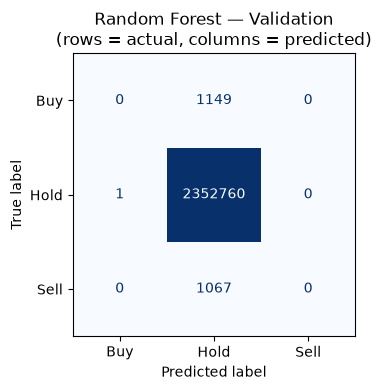

===== SVM (linear) — Validation =====
              precision    recall  f1-score   support

         Buy     0.0000    0.0000    0.0000      1149
        Hold     0.9991    1.0000    0.9995   2352761
        Sell     0.0000    0.0000    0.0000      1067

    accuracy                         0.9991   2354977
   macro avg     0.3330    0.3333    0.3332   2354977
weighted avg     0.9981    0.9991    0.9986   2354977



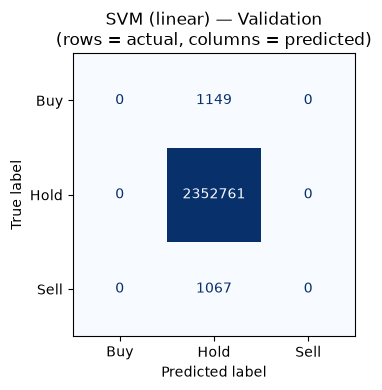

In [41]:
#Part 6: evaluation function and validation results
def slug(s):
    return re.sub(r'[^a-z0-9]+', '_', s.lower()).strip('_')

def evaluate(name, model, X, y, split):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    p_, r_, f_, _ = precision_recall_fscore_support(y, y_pred, labels=LABELS, zero_division=0)
    mp, mr, mf, _ = precision_recall_fscore_support(y, y_pred, labels=LABELS, average='macro', zero_division=0)

    print(f"===== {name} — {split} =====")
    print(classification_report(y, y_pred, labels=LABELS, target_names=CLASS_NAMES, zero_division=0, digits=4))

    cm = confusion_matrix(y, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'{name} — {split}\n(rows = actual, columns = predicted)')
    plt.tight_layout()
    plt.savefig(f"cm_{slug(split)}_{slug(name)}.png", dpi=150, bbox_inches='tight')
    plt.show()

    row = {'Model': name, 'Accuracy': acc, 'Macro Precision': mp, 'Macro Recall': mr, 'Macro F1': mf}
    for i, cls in enumerate(CLASS_NAMES):
        row[f'{cls} Precision'], row[f'{cls} Recall'], row[f'{cls} F1'] = p_[i], r_[i], f_[i]
    return row

always_hold_val = (y_val == LABEL_MAP['Hold']).mean()
print(f"Reference: accuracy of ALWAYS predicting Hold on validation = {always_hold_val:.4%}\n")

val_results = [evaluate(name, m, X_val_s, y_val, 'Validation') for name, m in trained.items()]

In [42]:
#Model comparison table(validation)
SUMMARY_COLS = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1',
                'Buy Precision', 'Buy Recall', 'Buy F1', 'Sell Precision', 'Sell Recall', 'Sell F1']
val_table = pd.DataFrame(val_results).set_index('Model')
val_table[SUMMARY_COLS]

,Accuracy,Macro Precision,Macro Recall,Macro F1,Buy Precision,Buy Recall,Buy F1,Sell Precision,Sell Recall,Sell F1
Model,,,,,,,,,,
Logistic Regression,0.9991,0.3330,0.3333,0.3332,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Random Forest,0.9991,0.3330,0.3333,0.3332,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
SVM (linear),0.9991,0.3330,0.3333,0.3332,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [43]:
for name, m in trained.items():
    print(name, pd.Series(m.predict(X_val_s)).map(dict(enumerate(CLASS_NAMES))).value_counts().to_dict())

Logistic Regression {'Hold': 2354977}
Random Forest {'Hold': 2354976, 'Buy': 1}
SVM (linear) {'Hold': 2354977}


Balanced training sample: 303,349 rows   classes: {'Buy': 1159, 'Hold': 300000, 'Sell': 2190}
Improved Random Forest trained in 24.3s
===== Random Forest (improved) — Validation =====
              precision    recall  f1-score   support

         Buy     0.0046    0.3708    0.0090      1149
        Hold     0.9994    0.7928    0.8842   2352761
        Sell     0.0013    0.4808    0.0026      1067

    accuracy                         0.7925   2354977
   macro avg     0.3351    0.5481    0.2986   2354977
weighted avg     0.9984    0.7925    0.8834   2354977



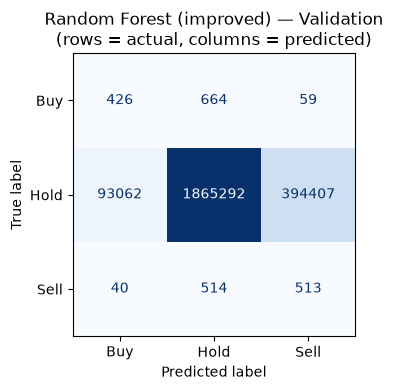

In [44]:
#Part 7: improved Random Forest
HOLD_SAMPLE = 300_000
rng = np.random.default_rng(RANDOM_STATE)
minority_pos = np.where(y_train != LABEL_MAP['Hold'])[0]
hold_pos = np.where(y_train == LABEL_MAP['Hold'])[0]
hold_pos = rng.choice(hold_pos, size=min(HOLD_SAMPLE, len(hold_pos)), replace=False)
bal_pos = np.sort(np.concatenate([minority_pos, hold_pos]))
X_bal, y_bal = X_train_s[bal_pos], y_train[bal_pos]
print(f"Balanced training sample: {len(y_bal):,} rows   classes: {class_counts(y_bal)}")

rf_improved = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=20,
    class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)

t0 = time.time()
rf_improved.fit(X_bal, y_bal)
trained['Random Forest (improved)'] = rf_improved
print(f"Improved Random Forest trained in {time.time() - t0:.1f}s")

improved_val = evaluate('Random Forest (improved)', rf_improved, X_val_s, y_val, 'Validation')

In [45]:
#Befoe vs after table
before_after = pd.DataFrame({
    'Before (baseline)': val_table.loc['Random Forest', SUMMARY_COLS],
    'After (improved)': pd.Series(improved_val)[SUMMARY_COLS].astype(float),
})
before_after['Change'] = before_after['After (improved)'] - before_after['Before (baseline)']
before_after

,Before (baseline),After (improved),Change
Accuracy,0.9991,0.7925,-0.2066
Macro Precision,0.3330,0.3351,0.0021
Macro Recall,0.3333,0.5481,0.2148
Macro F1,0.3332,0.2986,-0.0346
Buy Precision,0.0000,0.0046,0.0046
Buy Recall,0.0000,0.3708,0.3708
Buy F1,0.0000,0.0090,0.0090
Sell Precision,0.0000,0.0013,0.0013
Sell Recall,0.0000,0.4808,0.4808
Sell F1,0.0000,0.0026,0.0026


In [46]:
#Minority- class change summary
b, a = before_after['Before (baseline)'], before_after['After (improved)']
print("Part 7 — did performance on the minority classes change? (validation)")
for cls in ['Buy', 'Sell']:
    print(f"  {cls}: recall {b[cls+' Recall']:.3f} -> {a[cls+' Recall']:.3f}, "
          f"precision {b[cls+' Precision']:.3f} -> {a[cls+' Precision']:.3f}, "
          f"F1 {b[cls+' F1']:.3f} -> {a[cls+' F1']:.3f}")
print(f"  Accuracy {b['Accuracy']:.4f} -> {a['Accuracy']:.4f}  |  Macro F1 {b['Macro F1']:.3f} -> {a['Macro F1']:.3f}")

Part 7 — did performance on the minority classes change? (validation)
  Buy: recall 0.000 -> 0.371, precision 0.000 -> 0.005, F1 0.000 -> 0.009
  Sell: recall 0.000 -> 0.481, precision 0.000 -> 0.001, F1 0.000 -> 0.003
  Accuracy 0.9991 -> 0.7925  |  Macro F1 0.333 -> 0.299


In [59]:
#Time- ordered tunning smaple and CV folds
# Put the training rows in DATE order (train is sorted by ticker, then date)
date_order = np.argsort(train['date'].to_numpy(), kind='stable')
X_tr_time = X_train_s[date_order]
y_tr_time = y_train[date_order]
d_tr_time = train['date'].to_numpy()[date_order]

# Stratified sample of positions; positions are sorted, so date order is kept
TUNE_SIZE = 300_000
pos_t, y_tune = stratified_sample(np.arange(len(y_tr_time)), y_tr_time, TUNE_SIZE)
X_tune = X_tr_time[pos_t]
d_tune = d_tr_time[pos_t]
print(f"Tuning sample: {len(y_tune):,} rows  {class_counts(y_tune)}\n")

tscv = TimeSeriesSplit(n_splits=3)
for i, (tr_idx, va_idx) in enumerate(tscv.split(X_tune), 1):
    print(f"Fold {i}: train {pd.Timestamp(d_tune[tr_idx[0]]).date()} -> {pd.Timestamp(d_tune[tr_idx[-1]]).date()} "
          f"({len(tr_idx):,} rows) | validate {pd.Timestamp(d_tune[va_idx[0]]).date()} -> "
          f"{pd.Timestamp(d_tune[va_idx[-1]]).date()} ({len(va_idx):,} rows) | "
          f"validation classes {class_counts(y_tune[va_idx])}")

Tuning sample: 299,999 rows  {'Buy': 78, 'Hold': 299773, 'Sell': 148}

Fold 1: train 2010-04-15 -> 2011-08-04 (75,002 rows) | validate 2011-08-04 -> 2012-10-23 (74,999 rows) | validation classes {'Buy': 22, 'Hold': 74946, 'Sell': 31}
Fold 2: train 2010-04-15 -> 2012-10-23 (150,001 rows) | validate 2012-10-23 -> 2013-12-16 (74,999 rows) | validation classes {'Buy': 14, 'Hold': 74944, 'Sell': 41}
Fold 3: train 2010-04-15 -> 2013-12-16 (225,000 rows) | validate 2013-12-16 -> 2014-12-31 (74,999 rows) | validation classes {'Buy': 28, 'Hold': 74941, 'Sell': 30}


In [53]:
#Hyperparameter search with cross-validation
search_space = {
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {'C': [0.01, 0.1, 1, 10], 'class_weight': [None, 'balanced']}),
    'Random Forest': (
        RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
        {'max_depth': [8, 12], 'min_samples_leaf': [20, 50],
         'class_weight': [None, 'balanced_subsample']}),
    'SVM (linear)': (
        LinearSVC(dual=False, max_iter=5000, random_state=RANDOM_STATE),
        {'C': [0.01, 0.1, 1], 'class_weight': [None, 'balanced']}),
}

tuned, cv_rows, cv_details = {}, [], {}
for name, (estimator, grid) in search_space.items():
    gs = GridSearchCV(estimator, grid, scoring='f1_macro', cv=tscv, n_jobs=1, refit=True)
    t0 = time.time()
    gs.fit(X_tune, y_tune)
    secs = time.time() - t0

    tuned[f'{name} (tuned)'] = gs.best_estimator_
    res = pd.DataFrame(gs.cv_results_)
    cv_details[name] = (res[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
                          .sort_values('rank_test_score').reset_index(drop=True))
    best = res.loc[gs.best_index_]
    fold_scores = [best[f'split{i}_test_score'] for i in range(tscv.n_splits)]

    cv_rows.append({'Model': name, 'Best parameters': gs.best_params_,
                    'CV macro F1 (mean)': best['mean_test_score'],
                    'CV macro F1 (std)': best['std_test_score'],
                    'Fold scores': [round(s, 3) for s in fold_scores],
                    'Search time (s)': round(secs, 1)})
    print(f"{name:<20} best {gs.best_params_}  CV macro F1 = "
          f"{best['mean_test_score']:.3f} ± {best['std_test_score']:.3f}  ({secs:.0f}s)")

cv_summary = pd.DataFrame(cv_rows).set_index('Model')
cv_summary

Logistic Regression  best {'C': 0.01, 'class_weight': None}  CV macro F1 = 0.333 ± 0.000  (33s)
Random Forest        best {'class_weight': None, 'max_depth': 8, 'min_samples_leaf': 20}  CV macro F1 = 0.333 ± 0.000  (128s)
SVM (linear)         best {'C': 0.01, 'class_weight': 'balanced'}  CV macro F1 = 0.334 ± 0.002  (16s)


,Best parameters,CV macro F1 (mean),CV macro F1 (std),Fold scores,Search time (s)
Model,,,,,
Logistic Regression,"{'C': 0.01, 'class_weight': None}",0.3332,0.0000,"[0.333, 0.333, 0.333]",32.9000
Random Forest,"{'class_weight': None, 'max_depth': 8, 'min_sa...",0.3332,0.0000,"[0.333, 0.333, 0.333]",127.6000
SVM (linear),"{'C': 0.01, 'class_weight': 'balanced'}",0.3341,0.0018,"[0.337, 0.333, 0.333]",15.8000


In [54]:
#Full grid results (every setting that was tried)
for name, table in cv_details.items():
    print(f"\n===== {name}: all settings tried (ranked by CV macro F1) =====")
    print(table.to_string())


===== Logistic Regression: all settings tried (ranked by CV macro F1) =====
                                    params  mean_test_score  std_test_score  rank_test_score
0        {'C': 0.01, 'class_weight': None}           0.3332          0.0000                1
1         {'C': 0.1, 'class_weight': None}           0.3332          0.0000                1
2          {'C': 10, 'class_weight': None}           0.3332          0.0000                1
3           {'C': 1, 'class_weight': None}           0.3332          0.0000                1
4    {'C': 10, 'class_weight': 'balanced'}           0.2484          0.0032                5
5     {'C': 1, 'class_weight': 'balanced'}           0.2327          0.0059                6
6   {'C': 0.1, 'class_weight': 'balanced'}           0.2035          0.0086                7
7  {'C': 0.01, 'class_weight': 'balanced'}           0.1861          0.0132                8

===== Random Forest: all settings tried (ranked by CV macro F1) =====
               

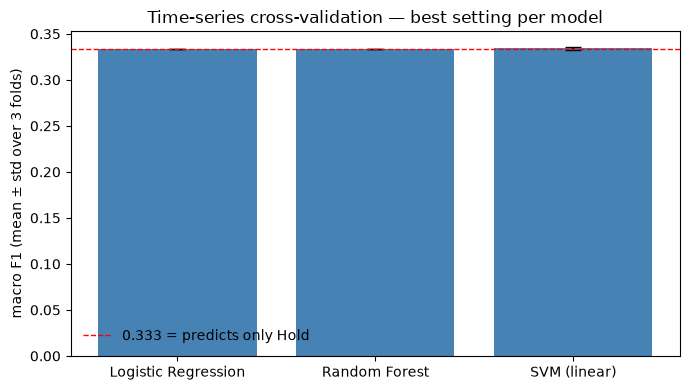

In [55]:
#cross-validation robustness chart
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cv_summary.index, cv_summary['CV macro F1 (mean)'],
       yerr=cv_summary['CV macro F1 (std)'], capsize=6, color='steelblue')
ax.axhline(1/3, color='red', ls='--', lw=1, label='0.333 = predicts only Hold')
ax.set_ylabel('macro F1 (mean ± std over 3 folds)')
ax.set_title('Time-series cross-validation — best setting per model')
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig('fig_cv_results.png', dpi=150, bbox_inches='tight'); plt.show()

Reference: accuracy of ALWAYS predicting Hold on test = 99.8979%

===== Logistic Regression — Test =====
              precision    recall  f1-score   support

         Buy     0.0000    0.0000    0.0000       862
        Hold     0.9990    1.0000    0.9995   2153721
        Sell     0.0000    0.0000    0.0000      1339

    accuracy                         0.9990   2155922
   macro avg     0.3330    0.3333    0.3332   2155922
weighted avg     0.9980    0.9990    0.9985   2155922



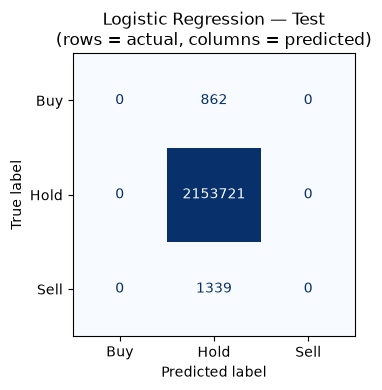

===== Random Forest — Test =====
              precision    recall  f1-score   support

         Buy     0.0000    0.0000    0.0000       862
        Hold     0.9990    1.0000    0.9995   2153721
        Sell     0.0000    0.0000    0.0000      1339

    accuracy                         0.9990   2155922
   macro avg     0.3330    0.3333    0.3332   2155922
weighted avg     0.9980    0.9990    0.9985   2155922



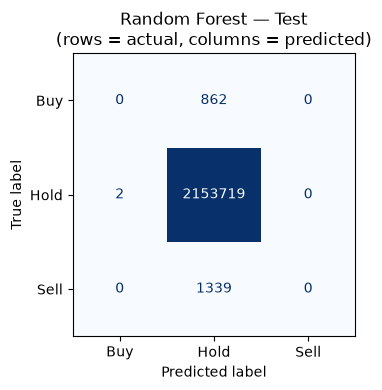

===== SVM (linear) — Test =====
              precision    recall  f1-score   support

         Buy     0.0000    0.0000    0.0000       862
        Hold     0.9990    1.0000    0.9995   2153721
        Sell     0.0000    0.0000    0.0000      1339

    accuracy                         0.9990   2155922
   macro avg     0.3330    0.3333    0.3332   2155922
weighted avg     0.9980    0.9990    0.9985   2155922



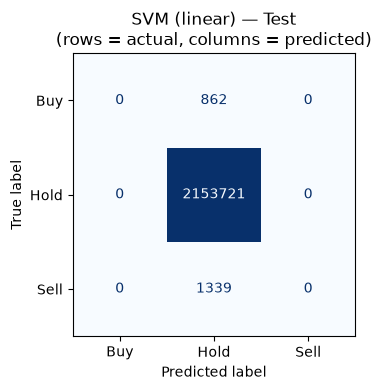

===== Random Forest (improved) — Test =====
              precision    recall  f1-score   support

         Buy     0.0043    0.4304    0.0085       862
        Hold     0.9994    0.7543    0.8597   2153721
        Sell     0.0016    0.5198    0.0031      1339

    accuracy                         0.7540   2155922
   macro avg     0.3351    0.5682    0.2904   2155922
weighted avg     0.9984    0.7540    0.8588   2155922



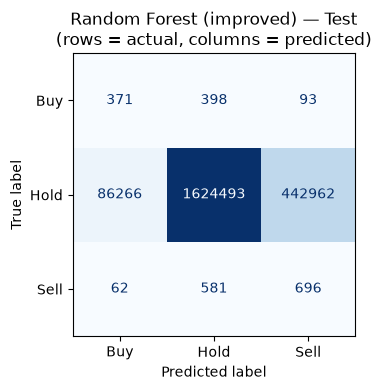

===== Logistic Regression (tuned) — Test =====
              precision    recall  f1-score   support

         Buy     0.0000    0.0000    0.0000       862
        Hold     0.9990    1.0000    0.9995   2153721
        Sell     0.0000    0.0000    0.0000      1339

    accuracy                         0.9990   2155922
   macro avg     0.3330    0.3333    0.3332   2155922
weighted avg     0.9980    0.9990    0.9985   2155922



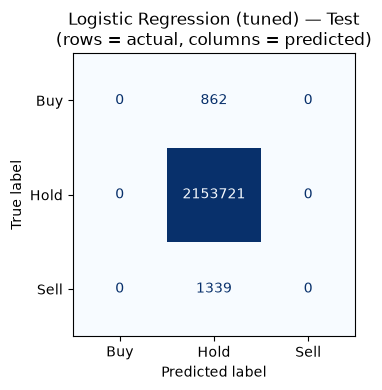

===== Random Forest (tuned) — Test =====
              precision    recall  f1-score   support

         Buy     0.0000    0.0000    0.0000       862
        Hold     0.9990    1.0000    0.9995   2153721
        Sell     0.0000    0.0000    0.0000      1339

    accuracy                         0.9990   2155922
   macro avg     0.3330    0.3333    0.3332   2155922
weighted avg     0.9980    0.9990    0.9985   2155922



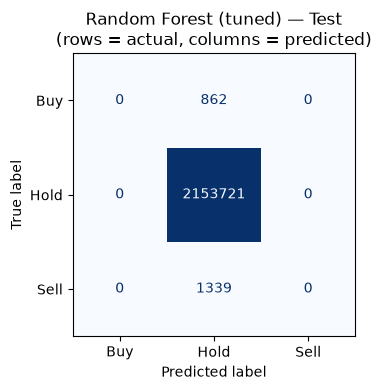

===== SVM (linear) (tuned) — Test =====
              precision    recall  f1-score   support

         Buy     0.0102    0.0638    0.0176       862
        Hold     0.9990    0.9969    0.9980   2153721
        Sell     0.0038    0.0037    0.0038      1339

    accuracy                         0.9959   2155922
   macro avg     0.3377    0.3548    0.3398   2155922
weighted avg     0.9980    0.9959    0.9970   2155922



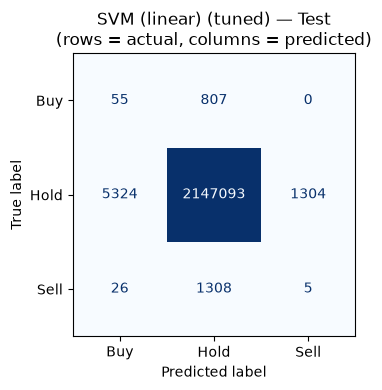

,Accuracy,Macro Precision,Macro Recall,Macro F1,Buy Precision,Buy Recall,Buy F1,Sell Precision,Sell Recall,Sell F1
Model,,,,,,,,,,
Logistic Regression,0.9990,0.3330,0.3333,0.3332,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Random Forest,0.9990,0.3330,0.3333,0.3332,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
SVM (linear),0.9990,0.3330,0.3333,0.3332,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Random Forest (improved),0.7540,0.3351,0.5682,0.2904,0.0043,0.4304,0.0085,0.0016,0.5198,0.0031
Logistic Regression (tuned),0.9990,0.3330,0.3333,0.3332,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Random Forest (tuned),0.9990,0.3330,0.3333,0.3332,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
SVM (linear) (tuned),0.9959,0.3377,0.3548,0.3398,0.0102,0.0638,0.0176,0.0038,0.0037,0.0038


In [56]:
#Evaluate all models on the test set 
always_hold_test = (y_test == LABEL_MAP['Hold']).mean()
print(f"Reference: accuracy of ALWAYS predicting Hold on test = {always_hold_test:.4%}\n")

all_models = {**trained, **tuned}    # baselines (+ Part 7 improved RF) + tuned models
test_results = [evaluate(name, m, X_test_s, y_test, 'Test') for name, m in all_models.items()]
final_table = pd.DataFrame(test_results).set_index('Model')

final_table.to_csv('results_test_table.csv')
cv_summary.to_csv('results_cv_summary.csv')
final_table[SUMMARY_COLS]

In [57]:
#Before vs afteer optimization (test set)
compare_cols = ['Accuracy', 'Macro F1', 'Buy Recall', 'Buy Precision', 'Sell Recall', 'Sell Precision']
rows = []
for base in ['Logistic Regression', 'Random Forest', 'SVM (linear)']:
    for label, key in [('Before (baseline)', base), ('After (tuned)', f'{base} (tuned)')]:
        rows.append({'Model': base, 'Version': label, **final_table.loc[key, compare_cols].to_dict()})

before_after_tuning = pd.DataFrame(rows).set_index(['Model', 'Version'])
before_after_tuning

Accuracy  Macro F1  Buy Recall  Buy Precision  Sell Recall  Sell Precision
Model               Version                                                                                      
Logistic Regression Before (baseline)    0.9990    0.3332      0.0000         0.0000       0.0000          0.0000
                    After (tuned)        0.9990    0.3332      0.0000         0.0000       0.0000          0.0000
Random Forest       Before (baseline)    0.9990    0.3332      0.0000         0.0000       0.0000          0.0000
                    After (tuned)        0.9990    0.3332      0.0000         0.0000       0.0000          0.0000
SVM (linear)        Before (baseline)    0.9990    0.3332      0.0000         0.0000       0.0000          0.0000
                    After (tuned)        0.9959    0.3398      0.0638         0.0102       0.0037          0.0038

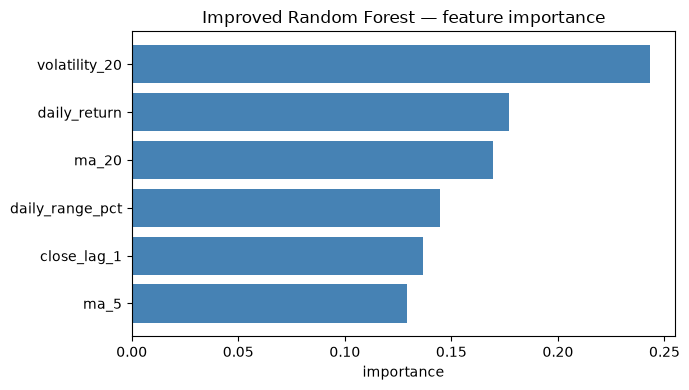

volatility_20     0.2430
daily_return      0.1770
ma_20             0.1694
daily_range_pct   0.1448
close_lag_1       0.1365
ma_5              0.1293
dtype: float64

In [48]:
#Feature importance
importances = pd.Series(rf_improved.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importances.index, importances.values, color='steelblue')
ax.set_title('Improved Random Forest — feature importance')
ax.set_xlabel('importance')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
importances.sort_values(ascending=False)

In [58]:
#Part 8: 
ft = final_table
baselines = ['Logistic Regression', 'Random Forest', 'SVM (linear)']
ft['Buy+Sell F1'] = ft[['Buy F1', 'Sell F1']].mean(axis=1)
best = ft['Buy+Sell F1'].idxmax()

print("Q1. Per-class recall on the test set:")
print(ft[['Buy Recall', 'Hold Recall', 'Sell Recall']].round(4).to_string(), "\n")
print(f"    Best model on the rare classes (mean Buy/Sell F1): {best} ({ft.loc[best, 'Buy+Sell F1']:.3f})\n")

print("Q2. Did high accuracy correspond to good Buy/Sell performance?")
for m in baselines:
    print(f"    {m:<20} accuracy {ft.loc[m, 'Accuracy']:.4%}  |  Buy recall {ft.loc[m, 'Buy Recall']:.3f}  "
          f"|  Sell recall {ft.loc[m, 'Sell Recall']:.3f}")
print(f"    'Always Hold' accuracy for comparison: {always_hold_test:.4%}\n")

rb, ri = ft.loc['Random Forest'], ft.loc['Random Forest (improved)']
print("Q3/Q4. Random Forest before vs after addressing imbalance (test):")
for col in ['Accuracy', 'Buy Recall', 'Buy Precision', 'Sell Recall', 'Sell Precision', 'Macro F1']:
    print(f"    {col:<15} {rb[col]:.4f} -> {ri[col]:.4f}")
print()

print("Q5. Feature importance ranking (improved Random Forest):")
for i, (feat, imp) in enumerate(importances.sort_values(ascending=False).items(), 1):
    print(f"    {i}. {feat:<16} {imp:.3f}")

Q1. Per-class recall on the test set:
                             Buy Recall  Hold Recall  Sell Recall
Model                                                            
Logistic Regression              0.0000       1.0000       0.0000
Random Forest                    0.0000       1.0000       0.0000
SVM (linear)                     0.0000       1.0000       0.0000
Random Forest (improved)         0.4304       0.7543       0.5198
Logistic Regression (tuned)      0.0000       1.0000       0.0000
Random Forest (tuned)            0.0000       1.0000       0.0000
SVM (linear) (tuned)             0.0638       0.9969       0.0037 

    Best model on the rare classes (mean Buy/Sell F1): SVM (linear) (tuned) (0.011)

Q2. Did high accuracy correspond to good Buy/Sell performance?
    Logistic Regression  accuracy 99.8979%  |  Buy recall 0.000  |  Sell recall 0.000
    Random Forest        accuracy 99.8978%  |  Buy recall 0.000  |  Sell recall 0.000
    SVM (linear)         accuracy 99.8979%  | 

In [64]:
#Save in csv and github
os.makedirs('results', exist_ok=True)
GITHUB_LIMIT_MB = 100

def save_csv(obj, filename, index=True):
    path = os.path.join('results', filename)
    obj.to_csv(path, index=index)
    size_mb = os.path.getsize(path) / 1e6
    print(f"saved {path:<45} {size_mb:>8.2f} MB")
    return size_mb

#1. Results tables (small, safe for GitHub) 
tables = {
    'signal_counts.csv':           'signal_table',
    'split_class_distribution.csv':'split_dist',
    'clip_limits.csv':             'clip_limits',
    'training_log.csv':            'training_log',
    'validation_results.csv':      'val_table',
    'rf_before_after_part7.csv':   'before_after',
    'cv_summary.csv':              'cv_summary',
    'test_results.csv':            'final_table',
    'before_after_tuning.csv':     'before_after_tuning',
    'feature_importance.csv':      'importances',
}
for filename, var in tables.items():
    if var in globals():
        obj = globals()[var]
        if isinstance(obj, list):               # training_log is a list of dicts
            obj = pd.DataFrame(obj)
        save_csv(obj, filename)
    else:
        print(f"skipped {filename} ('{var}' not found, run its cell first)")

#2. Buy/Sell signal rows only (small) 
signal_cols = ['ticker', 'date', 'close', 'macd', 'macd_signal_line', 'macd_action',
               'rsi_14', 'rsi_action', 'trading_signal'] + FEATURES
signals_only = s_p3.loc[s_p3['trading_signal'] != 'Hold', signal_cols]
save_csv(signals_only, 'buy_sell_signals.csv', index=False)

#3. Full dataset with signals (only if it fits GitHub)
full_path = os.path.join('results', 'trading_signals_full.csv.gz')
s_p3[signal_cols].to_csv(full_path, index=False, compression='gzip')
full_mb = os.path.getsize(full_path) / 1e6
if full_mb > GITHUB_LIMIT_MB:
    os.remove(full_path)
    print(f"\nfull dataset is {full_mb:,.0f} MB compressed, over GitHub's {GITHUB_LIMIT_MB} MB limit, so it was removed.")
    sample = s_p3[signal_cols].sample(200_000, random_state=RANDOM_STATE).sort_values(['ticker', 'date'])
    save_csv(sample, 'trading_signals_sample_200k.csv', index=False)
else:
    print(f"saved {full_path:<45} {full_mb:>8.2f} MB")

print("\nFiles in results/:")
for f in sorted(os.listdir('results')):
    print("  ", f)

saved results\signal_counts.csv                         0.00 MB
saved results\split_class_distribution.csv              0.00 MB
saved results\clip_limits.csv                           0.00 MB
skipped training_log.csv ('training_log' not found, run its cell first)
saved results\validation_results.csv                    0.00 MB
saved results\rf_before_after_part7.csv                 0.00 MB
saved results\cv_summary.csv                            0.00 MB
saved results\test_results.csv                          0.00 MB
saved results\before_after_tuning.csv                   0.00 MB
saved results\feature_importance.csv                    0.00 MB
saved results\buy_sell_signals.csv                      1.68 MB

full dataset is 705 MB compressed, over GitHub's 100 MB limit, so it was removed.
saved results\trading_signals_sample_200k.csv          43.94 MB

Files in results/:
   before_after_tuning.csv
   buy_sell_signals.csv
   clip_limits.csv
   cv_summary.csv
   feature_importance.csv
   rf_b